# Cement technology abatement-cost comparison

Compare each cement technology independently with BAU at the same annual output. Bar height shows annualized incremental resource cost per tonne of direct CO2 avoided, and bar width shows that option's individual annual direct emissions avoided. The technologies are alternative full-output routes, so the widths are not additive and the figure is not a cumulative sector deployment curve. The cost numerator annualizes CAPEX and includes operating costs and applicable CCS transport and storage, while excluding product revenue and carbon payments. The table and figure display inline; the notebook does not write output files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_abatement_comparison import (
    DEFAULT_ABATEMENT_COMPARISON_TECHNOLOGIES,
    deterministic_cement_abatement_comparison,
    plot_cement_abatement_comparison,
    simulated_cement_abatement_comparison,
)
from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
)

pd.options.display.float_format = "{:,.3f}".format

## Settings

Deterministic mode uses expected inputs. Simulated mode uses aligned Monte Carlo draws; its headline cost is mean incremental annual cost divided by mean annual abatement, while p05/median/p95 summarize draw-level cost.

In [2]:
USE_SIMULATED = False
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = DEFAULT_ABATEMENT_COMPARISON_TECHNOLOGIES

mode_label = "simulated" if USE_SIMULATED else "deterministic"
print(f"Selected abatement-comparison mode: {mode_label}")
print(f"Technologies: {', '.join(TECHNOLOGIES)}")
if USE_SIMULATED:
    print(f"Monte Carlo draws: {SAMPLE_SIZE:,}")
    print(f"Random seed: {RANDOM_SEED}")
    print(f"Retrofit BAU mode: {RETROFIT_BAU_MODE}")

Selected abatement-comparison mode: deterministic
Technologies: electrification, electrolysis, clinker_substitution, alternative_fuels, efficiency_improvement, waste_heat_recovery, ccs, process_heat_integration


## Calculate abatement-comparison values

In [3]:
if USE_SIMULATED:
    comparison = simulated_cement_abatement_comparison(
        sample_size=SAMPLE_SIZE,
        random_seed=RANDOM_SEED,
        technologies=TECHNOLOGIES,
        retrofit_bau_mode=RETROFIT_BAU_MODE,
    )
else:
    comparison = deterministic_cement_abatement_comparison(technologies=TECHNOLOGIES)

display(comparison)

,technology,label,annual_abatement_tco2,annual_abatement_mtco2,abatement_share_of_bau,incremental_annual_cost_eur,abatement_cost_eur_per_tco2,abatement_cost_p05_eur_per_tco2,abatement_cost_median_eur_per_tco2,abatement_cost_p95_eur_per_tco2
0,efficiency_improvement,Efficiency improvement,"6,333.333",0.006,0.010,"-128,458.758",-20.283,-20.283,-20.283,-20.283
1,process_heat_integration,Process heat integration,"41,166.667",0.041,0.065,"55,731.330",1.354,1.354,1.354,1.354
2,alternative_fuels,Alternative fuels,"63,333.333",0.063,0.100,"2,017,512.112",31.855,31.855,31.855,31.855
3,clinker_substitution,Clinker substitution,"79,166.667",0.079,0.125,"3,070,333.333",38.783,38.783,38.783,38.783
4,ccs,CCS,"576,333.333",0.576,0.910,"50,166,614.343",87.044,87.044,87.044,87.044
5,electrification,Electrification,"233,333.333",0.233,0.368,"109,584,105.159",469.646,469.646,469.646,469.646
6,electrolysis,Electrolysis,"533,333.333",0.533,0.842,"302,135,893.335",566.505,566.505,566.505,566.505


## Plot abatement comparison

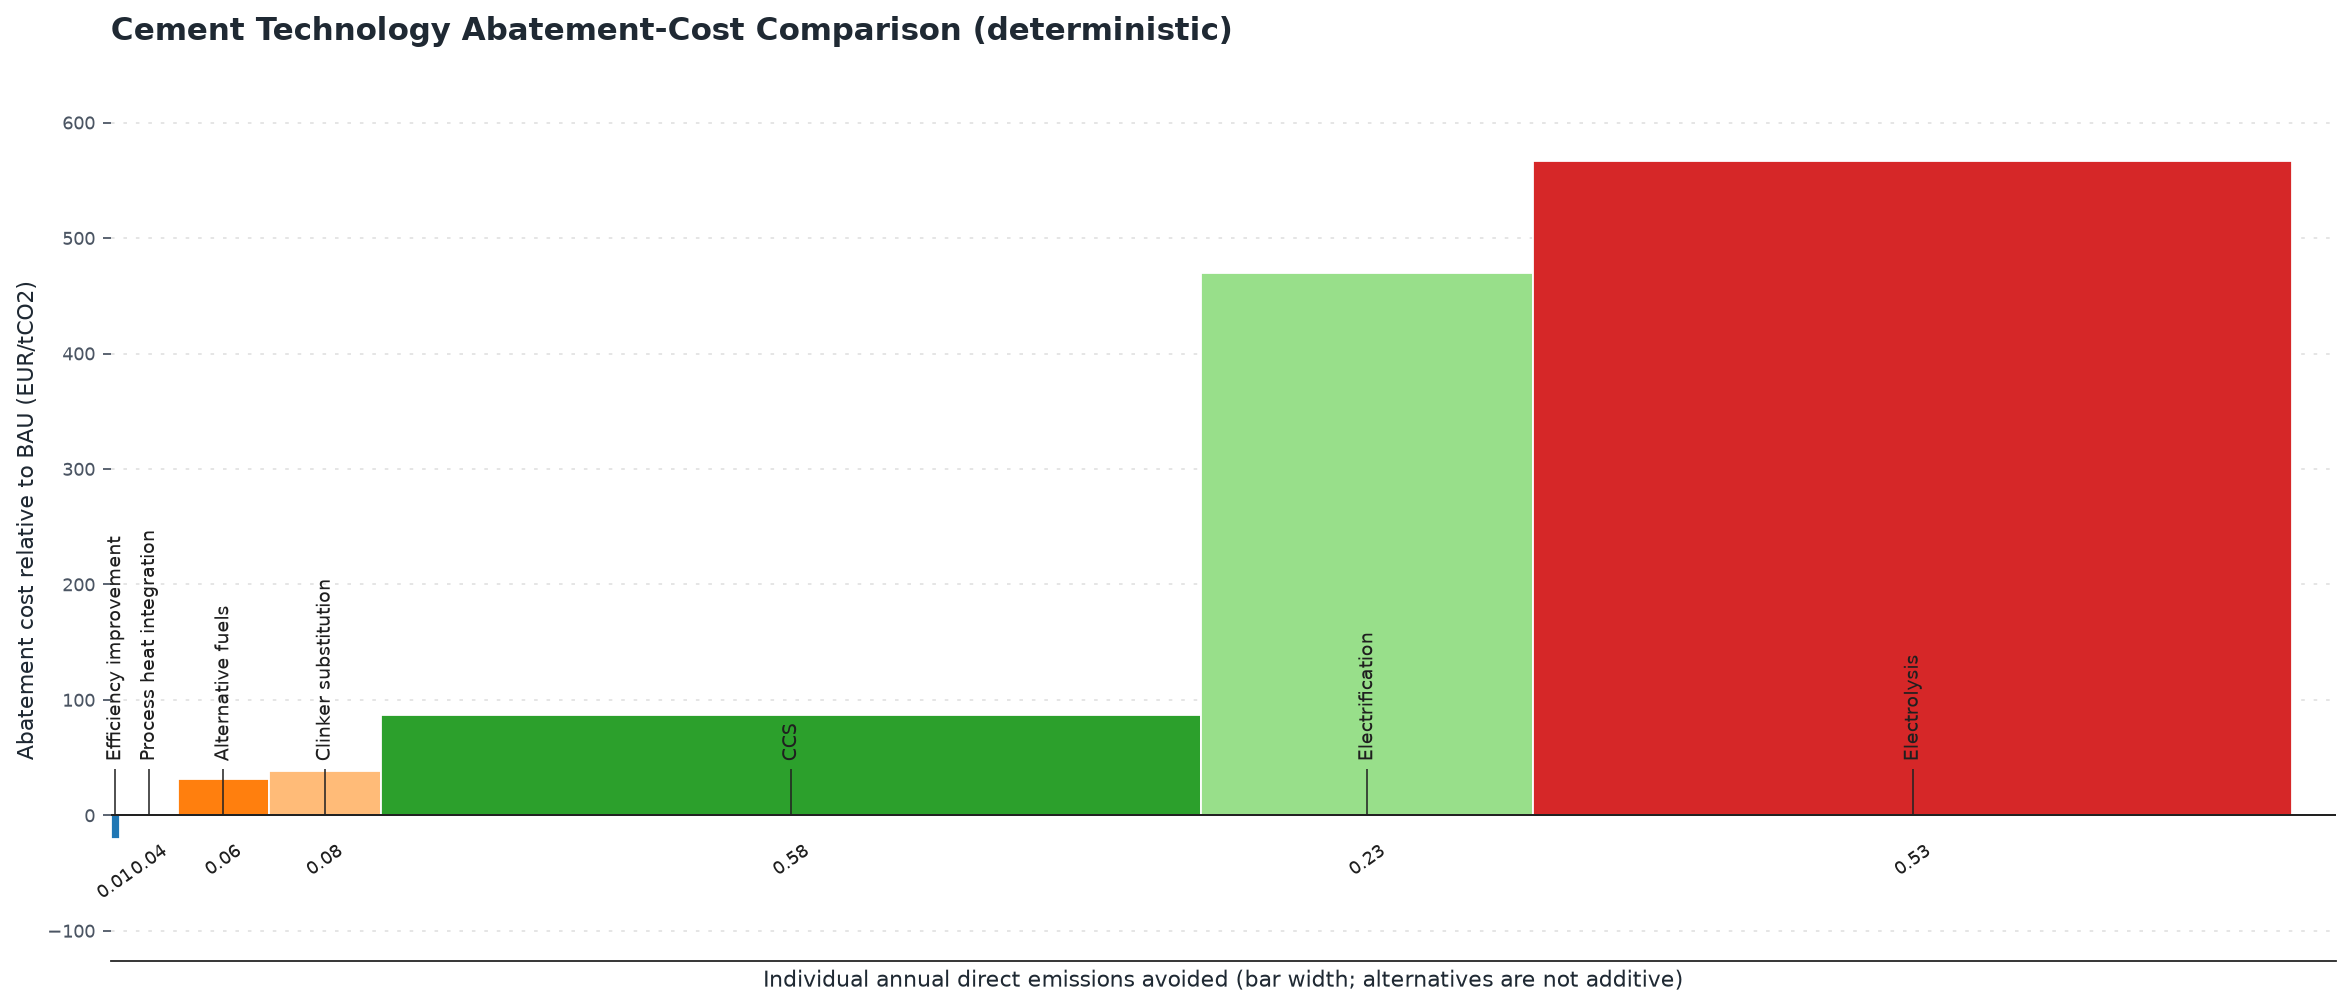

In [4]:
fig = plot_cement_abatement_comparison(
    comparison,
    title=f"Cement Technology Abatement-Cost Comparison ({mode_label})",
)
plt.show()
plt.close(fig)